# D-Fire · Interpretabilidad del YOLO26s final

## tl;dr

Se explican seis casos dirigidos de **validación**: acierto, falsa alarma y
omisión limítrofe para humo y fuego. La oclusión resulta informativa: al ocultar
el 25 % de las regiones más sensibles, la confianza cae una mediana del **96,2 %**,
frente al **24,4 %** con regiones aleatorias, y la perturbación dirigida es más
fuerte en **6/6 casos**.

Eigen-CAM aporta contexto espacial, pero su máximo cae dentro de la caja objetivo
solo en 1/6 casos; debe interpretarse como activación multiescala no específica de
clase. El máximo de oclusión cae dentro de la caja en 3/6 casos. El análisis no
consulta `test`, no cambia umbrales y no modifica el modelo final.

## Guía de lectura y ejecución

| Aspecto | Descripción |
|---|---|
| **Papel en el proyecto** | Análisis final: estudia qué regiones sostienen predicciones seleccionadas del YOLO26s. |
| **Cuándo abrirlo** | Abrir para revisar Eigen-CAM, oclusión, fidelidad y las limitaciones de las explicaciones. |
| **Comportamiento por defecto** | Solo consulta sobre validación; no cambia el modelo ni sus umbrales. |
| **Entradas principales** | Checkpoint final y seis casos dirigidos del split de validación. |
| **Salidas principales** | `results/interpretability` con mapas, métricas y resumen. |
| **Continuación** | Fin del flujo experimental documentado. |

> **Entorno:** abrir desde la raíz del repositorio o definir
> `TFM_PROJECT_ROOT`. La reproducción completa de entrenamientos necesita el
> dataset D-Fire y una GPU; la lectura de resultados guardados no.


## Contexto y métodos

El objetivo es responder dos preguntas locales: **dónde concentra actividad la
red** y **qué regiones afectan realmente a una detección concreta**.

### Supuestos clave

- Checkpoint congelado YOLO26s, entrenamiento e inferencia a 768.
- Umbrales operativos: humo 0,36 y fuego 0,16.
- Muestra dirigida y determinista; cubre tipos de comportamiento, pero no estima
  su frecuencia en el dataset.
- Las omisiones son limítrofes: existe una caja coincidente por debajo del umbral.
- Una explicación local describe el comportamiento del modelo, no la causa física
  de un incendio ni su robustez futura.

### Técnicas

1. **Eigen-CAM multiescala:** primera componente espacial de las capas 16, 19 y
   22 del cuello del detector (96×96, 48×48 y 24×24), deshaciendo el letterbox y
   promediando los mapas normalizados. No utiliza gradientes y no es específico
   de clase.
2. **Sensibilidad por oclusión:** divide la imagen en 6×6 regiones, sustituye cada
   una por su versión desenfocada y mide la caída relativa de la misma detección.
   La identidad se conserva eligiendo la caja de la misma clase con mayor IoU
   respecto a la caja original, siempre que IoU≥0,30.
3. **Prueba de eliminación:** compara la confianza retenida al ocultar regiones
   ordenadas por importancia frente a cinco selecciones aleatorias.

In [1]:
from pathlib import Path
import json
import subprocess
import pandas as pd
from IPython.display import display, Image

def find_root(start=Path.cwd()):
    for candidate in [start,*start.parents,Path('/workspace/TFM')]:
        if (candidate/'configs/model_interpretability.yaml').is_file(): return candidate.resolve()
    raise FileNotFoundError('No se encuentra la raíz del proyecto')

ROOT=find_root()
RUN_ANALYSIS=False  # Solo validación. La ejecución habitual reutiliza el artefacto verificado.
if RUN_ANALYSIS:
    subprocess.run(['python','tools/run_model_interpretability.py'],cwd=ROOT,check=True)

latest=json.loads((ROOT/'artifacts/16_model_interpretability/validation/latest.json').read_text(encoding='utf-8'))
RUN=ROOT/latest['run_rel']
summary=json.loads((RUN/'run_summary.json').read_text(encoding='utf-8'))
verification=json.loads((RUN/'verification_report.json').read_text(encoding='utf-8'))
assert summary['split']=='val' and summary['test_inference_executed'] is False
assert verification['status']=='passed' and verification['cases']==6
print(f"Artefacto: {RUN.relative_to(ROOT)}")
print(f"Modelo: {summary['model']['label']} · SHA-256 {summary['model']['weights_sha256']}")
print(f"Verificación: {verification['status']} · test consultado: {summary['test_inference_executed']}")

Artefacto: artifacts/16_model_interpretability/validation/20260915T154734Z_649d1859
Modelo: YOLO26s 768→768 · SHA-256 bfb54c4726519fb473bb7c4825577e51c05af2b0db5fd46bf1931a8a29285f67
Verificación: passed · test consultado: False


## Datos

### Selección de casos

Los aciertos se toman en el percentil central-alto de confianza para evitar
mostrar exclusivamente el caso más fácil. En falsas alarmas se selecciona la
más segura de cada clase; en omisiones, la detección coincidente más próxima al
umbral. Esta es una muestra para inspección cualitativa, no estadística.

In [2]:
selection=pd.read_csv(RUN/'selected_cases.csv')
selection_display=selection[['order','case','class_name','filename','category','cached_target_confidence','operating_threshold']].copy()
selection_display['case']=selection_display.case.map({'true_positive':'Acierto','negative_false_alarm':'Falsa alarma negativa','borderline_false_negative':'Omisión limítrofe'})
selection_display['class_name']=selection_display.class_name.map({'smoke':'Humo','fire':'Fuego'})
display(selection_display.style.format({'cached_target_confidence':'{:.3f}','operating_threshold':'{:.2f}'}))

,order,case,class_name,filename,category,cached_target_confidence,operating_threshold
0,1,Acierto,Humo,WEB06295.jpg,smoke,0.893,0.36
1,2,Acierto,Fuego,WEB03832.jpg,smoke+fire,0.841,0.16
2,3,Falsa alarma negativa,Humo,WEB00156.jpg,background,0.645,0.36
3,4,Falsa alarma negativa,Fuego,WEB02251.jpg,background,0.517,0.16
4,5,Omisión limítrofe,Humo,WEB05832.jpg,smoke+fire,0.357,0.36
5,6,Omisión limítrofe,Fuego,WEB05014.jpg,smoke+fire,0.160,0.16


## Resultados

### 1. Mapas explicativos

En cada fila: imagen y caja objetivo, Eigen-CAM, sensibilidad por oclusión y
resultado de ocultar la región individual más influyente. Azul identifica la
predicción seguida; la caja GT aparece discontinua cuando existe.

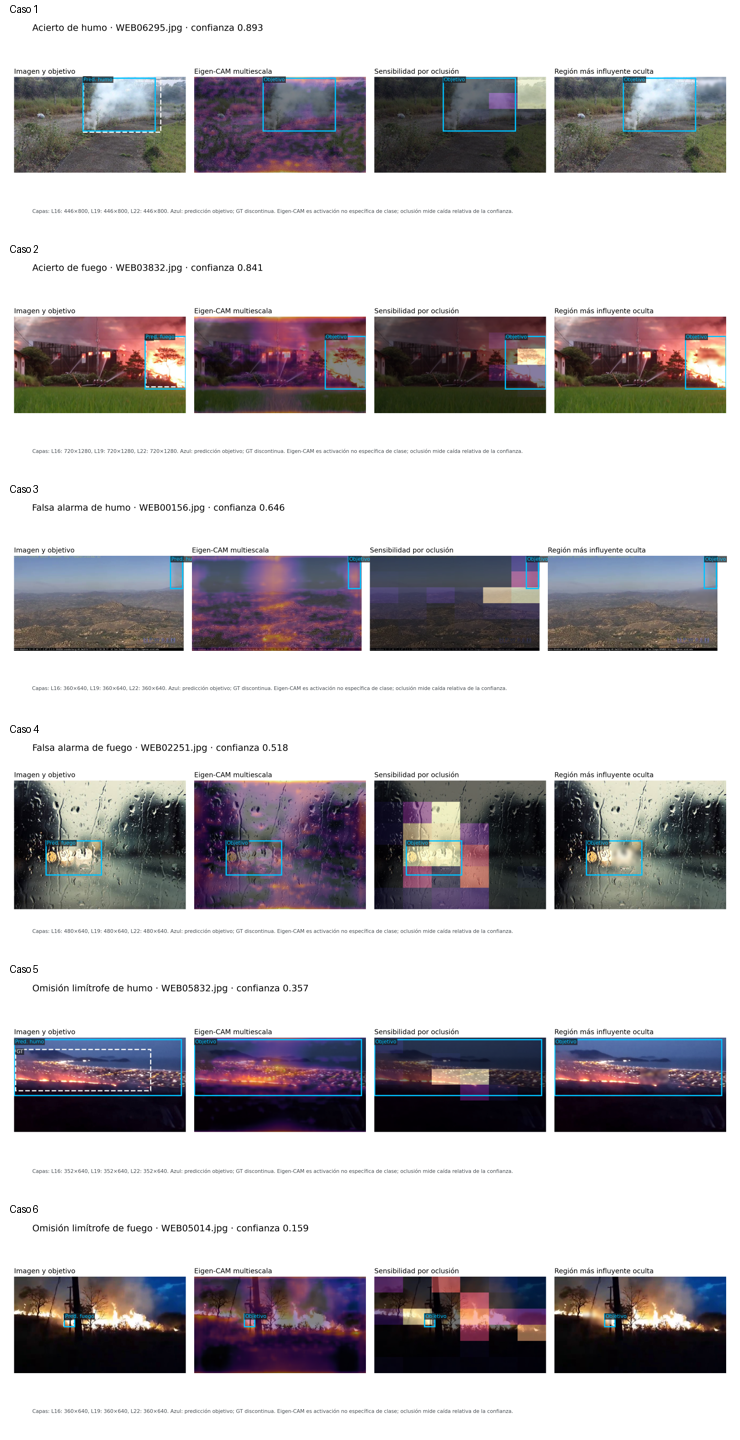

In [3]:
display(Image(filename=str(RUN/'figures/09_interpretability_contact_sheet.png'),width=1100))

Lectura de los casos:

- **Acierto de humo:** el mapa de oclusión depende también del contexto y no solo
  del interior de la caja; ocultar la región más influyente elimina casi toda la
  confianza.
- **Acierto de fuego:** el 98,4 % de la importancia positiva de oclusión queda
  dentro de la caja, un patrón local coherente con la detección.
- **Falsa alarma de humo:** la predicción aparece en el borde del paisaje; el mapa
  se reparte entre la caja y el contexto. Sugiere dependencia contextual, pero no
  identifica por sí solo una causa visual.
- **Falsa alarma de fuego:** la sensibilidad se concentra en el reflejo luminoso
  visto a través del parabrisas mojado. Es una hipótesis compatible con el mapa,
  no una demostración causal general.
- **Omisión limítrofe de humo:** tanto Eigen-CAM como oclusión se concentran en
  la zona anotada, pero la confianza 0,357 queda justo por debajo de 0,36.
- **Omisión limítrofe de fuego:** los mapas son difusos y la confianza 0,159 queda
  justo por debajo de 0,16; pequeñas perturbaciones pueden aumentarla, señal de
  inestabilidad local cerca del umbral.

### 2. Fidelidad cuantitativa

Una explicación por oclusión es más convincente cuando ocultar sus regiones de
mayor importancia reduce antes la confianza que ocultar regiones aleatorias.

In [4]:
metrics=pd.read_csv(RUN/'interpretability_metrics.csv')
metric_display=metrics[['order','case','class_name','fresh_target_confidence','max_single_occlusion_drop',
                        'top25_score_retained','random25_score_retained','occlusion_mass_in_target',
                        'occlusion_pointing_game','eigencam_mass_in_target','eigencam_pointing_game']].copy()
metric_display['case']=metric_display.case.map({'true_positive':'Acierto','negative_false_alarm':'Falsa alarma','borderline_false_negative':'Omisión'})
metric_display['class_name']=metric_display.class_name.map({'smoke':'Humo','fire':'Fuego'})
display(metric_display.style.format({c:'{:.1%}' for c in ['max_single_occlusion_drop','top25_score_retained','random25_score_retained','occlusion_mass_in_target','eigencam_mass_in_target']}).format({'fresh_target_confidence':'{:.3f}'}))

,order,case,class_name,fresh_target_confidence,max_single_occlusion_drop,top25_score_retained,random25_score_retained,occlusion_mass_in_target,occlusion_pointing_game,eigencam_mass_in_target,eigencam_pointing_game
0,1,Acierto,Humo,0.893,0.998880,0.003323,0.719208,0.153149,False,0.171103,False
1,2,Acierto,Fuego,0.841,0.934555,0.071903,0.793404,0.984097,True,0.055509,False
2,3,Falsa alarma,Humo,0.646,0.855534,0.000000,0.434151,0.437710,False,0.035129,False
3,4,Falsa alarma,Fuego,0.518,1.000000,0.000000,0.338425,0.736369,True,0.072112,False
4,5,Omisión,Humo,0.357,0.984069,0.127083,1.460025,0.986637,True,0.819110,True
5,6,Omisión,Fuego,0.159,0.546886,0.343433,2.148813,0.167494,False,0.012652,False


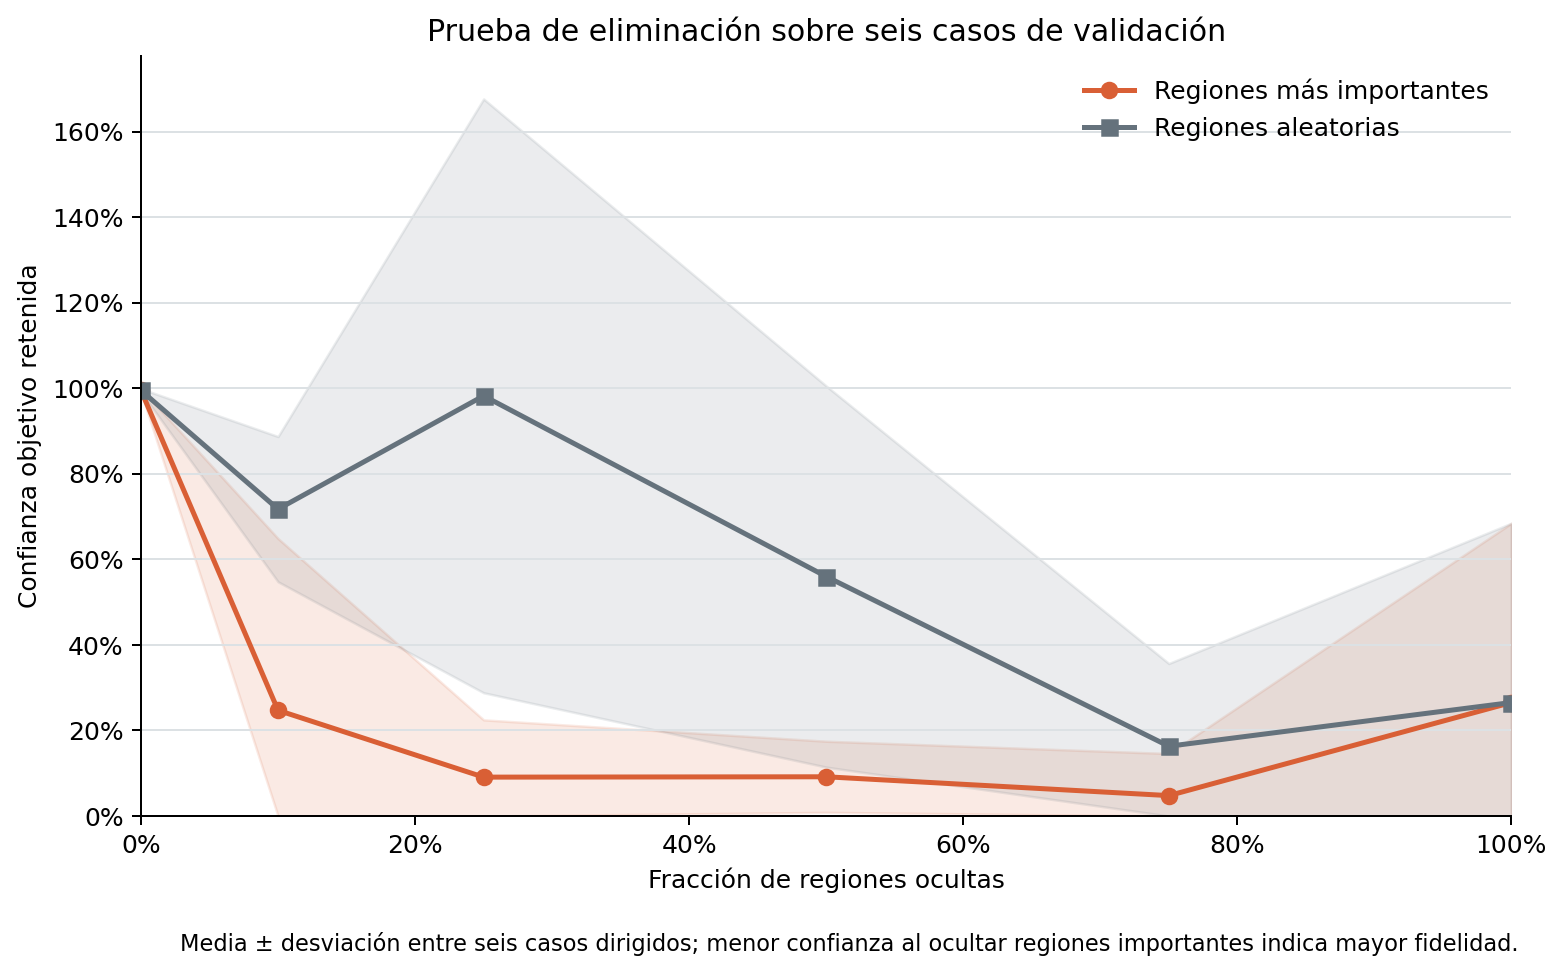

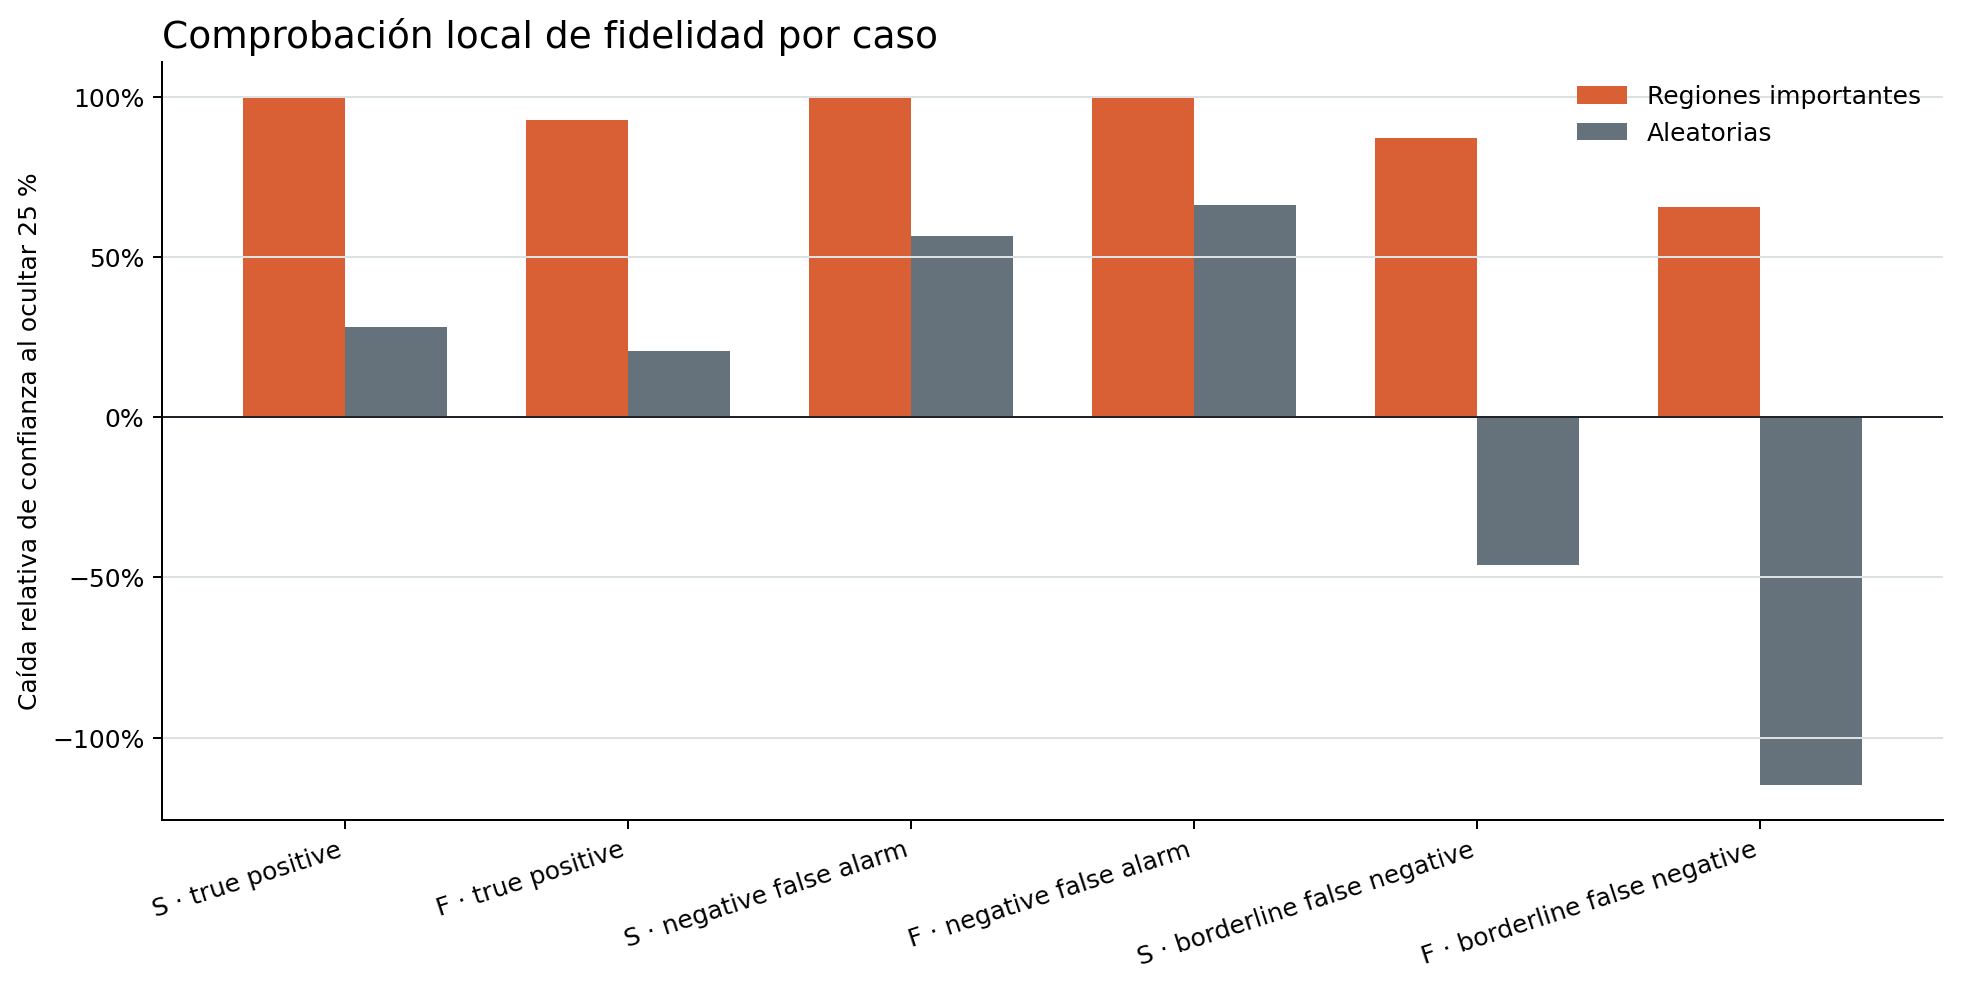

In [5]:
display(Image(filename=str(RUN/'figures/07_deletion_curve.png'),width=900))
display(Image(filename=str(RUN/'figures/08_faithfulness_by_case.png'),width=1000))

La curva confirma que las regiones ordenadas por oclusión contienen señal local:
la confianza cae mucho antes que con selecciones aleatorias. La curva no tiene
por qué ser monótona: desenfocar regiones puede suprimir evidencia competidora o
crear una caja alternativa. Esto es especialmente visible en las omisiones
limítrofes, donde algunas perturbaciones elevan la confianza por encima de su
valor original.

### 3. Comprobaciones de consistencia

In [6]:
curves=pd.read_csv(RUN/'deletion_curves.csv')
checks=pd.DataFrame([
    {'Comprobación':'Casos predefinidos cubiertos','Resultado':f"{len(selection)}/6"},
    {'Comprobación':'Mapas serializados','Resultado':f"{len(list((RUN/'maps').glob('*.npz')))}/6"},
    {'Comprobación':'Puntos de curva','Resultado':len(curves)},
    {'Comprobación':'Oclusión supera aleatorio al 25 %','Resultado':f"{int(metrics.top25_better_than_random.sum())}/6"},
    {'Comprobación':'Pointing game de oclusión','Resultado':f"{int(metrics.occlusion_pointing_game.sum())}/6"},
    {'Comprobación':'Pointing game de Eigen-CAM','Resultado':f"{int(metrics.eigencam_pointing_game.sum())}/6"},
    {'Comprobación':'Split utilizado','Resultado':summary['split']},
    {'Comprobación':'Inferencia en test','Resultado':summary['test_inference_executed']},
])
display(checks)

,Comprobación,Resultado
0,Casos predefinidos cubiertos,6/6
1,Mapas serializados,6/6
2,Puntos de curva,216
3,Oclusión supera aleatorio al 25 %,6/6
4,Pointing game de oclusión,3/6
5,Pointing game de Eigen-CAM,1/6
6,Split utilizado,val
7,Inferencia en test,False


## Takeaways

1. La oclusión es la explicación principal y más defendible: sus regiones
   priorizadas reducen más la confianza que las aleatorias en los seis casos.
2. El modelo puede apoyarse tanto en el objeto como en contexto global. Esto es
   visible en el acierto de humo, la falsa alarma de humo y la omisión de fuego.
3. La falsa alarma de fuego parece localmente asociada a reflejos luminosos y
   lluvia; debe presentarse como hipótesis de este caso, no como regla general.
4. Las dos omisiones están a menos de 0,003 del umbral correspondiente y muestran
   sensibilidad a perturbaciones. No representan todos los falsos negativos.
5. Eigen-CAM ayuda a visualizar activaciones internas, pero su baja coincidencia
   espacial confirma que no debe interpretarse como saliencia causal de clase.
6. El requisito de interpretabilidad queda cubierto sin utilizar test ni cambiar
   el modelo final.

## Limitaciones

- Seis ejemplos no cuantifican la interpretabilidad de todo el dataset.
- La rejilla 6×6 limita la resolución espacial y el desenfoque es una perturbación
  artificial.
- La detección se sigue por clase e IoU; con oclusiones fuertes puede desaparecer
  o ser sustituida por otra caja cercana.
- Los mapas no validan razonamiento humano, causalidad ni seguridad operacional.
- Para un estudio posterior podrían repetirse las pruebas con varias rejillas,
  más ejemplos preregistrados y anotaciones humanas de regiones relevantes.